# Tox21: exploring 7,800 chemicals and 12 toxicity tests

**Can we tell whether a molecule is toxic just from its structure?** That is the question behind *in silico* toxicology. Pharmaceutical and chemical companies use such models to screen out risky compounds before any lab work.

**Data:** the [Tox21 challenge](https://tripod.nih.gov/tox21/challenge/) dataset (US EPA, NIH and FDA), as distributed by [MoleculeNet](https://moleculenet.org/). It contains about 7,800 environmental chemicals and drugs. Each was tested in up to **12 high-throughput lab assays**, and each assay result is a yes/no: *active* (toxic signal) or *inactive*.

**Outline**
1. Molecules as data: SMILES and features
2. The 12 assays, in plain terms
3. Missing labels and class imbalance
4. Do the assays agree with each other?
5. What do active molecules look like?
6. Chemical diversity: scaffolds

> Run `python src/featurize.py` first. It downloads the data and computes fingerprints, descriptors and splits.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
import style
from featurize import ASSAYS
style.apply()

FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG / f"{name}.png", dpi=120)

def mol_grid(smiles, legends, name, per_row=4, size=(230, 180)):
    """Draw molecules in a grid, save it to figures/ and return it for display."""
    img = Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in smiles], molsPerRow=per_row,
                               subImgSize=size, legends=[str(l) for l in legends])
    path = FIG / f"{name}.png"
    if hasattr(img, "data"):   # inside Jupyter RDKit returns PNG bytes
        path.write_bytes(img.data)
    else:                      # plain Python returns a PIL image
        img.save(path)
    return img

PROC = ROOT / "data" / "processed"
mols = pd.read_parquet(PROC / "molecules.parquet")
desc = pd.read_parquet(PROC / "descriptors.parquet")
fps = np.load(PROC / "fingerprints.npy")
print(f"{len(mols):,} molecules, {desc.shape[1]} descriptors, {fps.shape[1]}-bit fingerprints")
mols.head()

7,823 molecules, 217 descriptors, 2048-bit fingerprints


,mol_id,smiles,smiles_clean,scaffold,split_random,split_scaffold,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,c1ccc2scnc2c1,test,train,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O,CCN1C(=O)NC(c2ccccc2)C1=O,O=C1NC(=O)C(c2ccccc2)N1,train,train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0
2,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,C1=C2CCC3C4CCCC4CCC3C2CCC1,train,train,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN
3,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,c1ccccc1,train,train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0
4,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O,CC(O)(P(=O)(O)O)P(=O)(O)O,,train,train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Molecules as data

Each molecule is stored as a **SMILES** string, a line of text that encodes atoms and bonds. For example, `CC(=O)Oc1ccccc1C(=O)O` is aspirin.
A model can't read SMILES directly, so `featurize.py` turned each molecule into two kinds of numbers:

- **Morgan fingerprint** (2,048 bits): each bit marks whether a small circular fragment, a group of atoms within 2 bonds of a centre atom, is present. It describes *which pieces* the molecule contains.
- **RDKit descriptors** (~200 numbers): whole-molecule properties such as molecular weight, logP (how fat-soluble it is), number of rings, polar surface area and so on.

Salts and counter-ions were stripped (only the largest fragment is kept). 8 SMILES couldn't be parsed and were dropped.

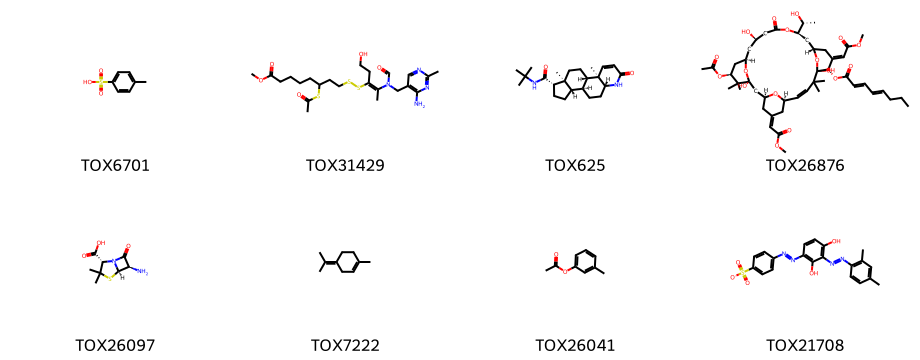

In [2]:
examples = mols.sample(8, random_state=3)
mol_grid(examples["smiles_clean"], examples["mol_id"], "01_example_molecules")

## 2. The 12 assays in plain terms

The assays fall into two families:
- **NR, nuclear receptor:** does the chemical switch on a hormone receptor? Such chemicals can act as *endocrine disruptors*. Examples are the androgen (AR) and oestrogen (ER) receptors, aromatase (which makes oestrogen), AhR (the "dioxin" receptor) and PPAR-γ (fat metabolism).
- **SR, stress response:** does the chemical trigger a cell's alarm systems? Examples are oxidative stress (ARE), DNA damage (ATAD5, p53), heat shock (HSE) and damage to mitochondria (MMP).

"LBD" assays test the same receptor using only its *ligand-binding domain*, a different lab setup for the same biology.

In [3]:
assay_info = pd.DataFrame({
    "family": ["Nuclear receptor"] * 7 + ["Stress response"] * 5,
    "what it detects": [
        "Activates the androgen (male hormone) receptor", "Same, ligand-binding domain only",
        "Activates the aryl hydrocarbon receptor (dioxin-like)", "Inhibits aromatase (oestrogen production)",
        "Activates the oestrogen receptor", "Same, ligand-binding domain only",
        "Activates PPAR-γ (fat and sugar metabolism)",
        "Oxidative stress response", "DNA damage (genotoxicity)", "Heat-shock (protein damage) response",
        "Damages mitochondria (cell energy)", "DNA damage via the p53 pathway",
    ],
}, index=ASSAYS)
assay_info

,family,what it detects
NR-AR,Nuclear receptor,Activates the androgen (male hormone) receptor
NR-AR-LBD,Nuclear receptor,"Same, ligand-binding domain only"
NR-AhR,Nuclear receptor,Activates the aryl hydrocarbon receptor (dioxi...
NR-Aromatase,Nuclear receptor,Inhibits aromatase (oestrogen production)
NR-ER,Nuclear receptor,Activates the oestrogen receptor
NR-ER-LBD,Nuclear receptor,"Same, ligand-binding domain only"
NR-PPAR-gamma,Nuclear receptor,Activates PPAR-γ (fat and sugar metabolism)
SR-ARE,Stress response,Oxidative stress response
SR-ATAD5,Stress response,DNA damage (genotoxicity)
SR-HSE,Stress response,Heat-shock (protein damage) response


## 3. Missing labels and class imbalance

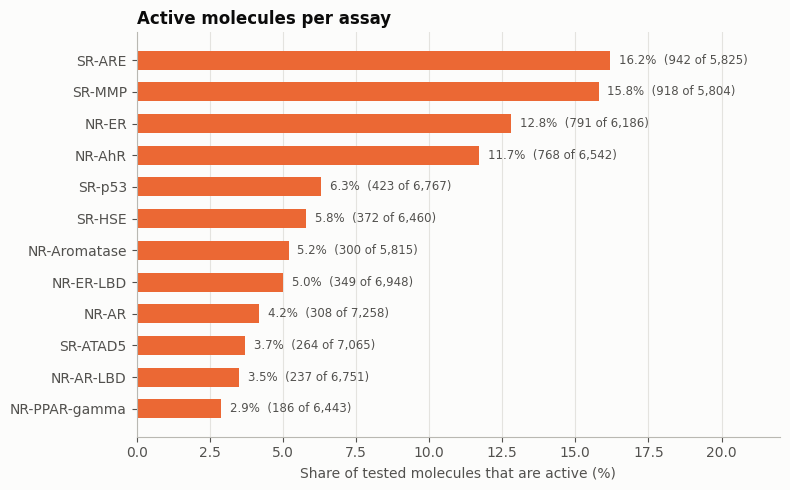

,tested,active,% active,% not tested
NR-AR,7258,308,4.2,7.2
NR-AR-LBD,6751,237,3.5,13.7
NR-AhR,6542,768,11.7,16.4
NR-Aromatase,5815,300,5.2,25.7
NR-ER,6186,791,12.8,20.9
NR-ER-LBD,6948,349,5.0,11.2
NR-PPAR-gamma,6443,186,2.9,17.6
SR-ARE,5825,942,16.2,25.5
SR-ATAD5,7065,264,3.7,9.7
SR-HSE,6460,372,5.8,17.4


In [4]:
summary = pd.DataFrame({
    "tested": mols[ASSAYS].notna().sum(),
    "active": (mols[ASSAYS] == 1).sum(),
})
summary["% active"] = (summary["active"] / summary["tested"] * 100).round(1)
summary["% not tested"] = (100 - summary["tested"] / len(mols) * 100).round(1)

order = summary.sort_values("% active").index
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(order, summary.loc[order, "% active"], color=style.ORANGE, height=0.6)
for i, a in enumerate(order):
    ax.text(summary.loc[a, "% active"] + 0.3, i, f"{summary.loc[a, '% active']:.1f}%  ({summary.loc[a, 'active']} of {summary.loc[a, 'tested']:,})",
            va="center", fontsize=8.5, color=style.TEXT_2)
ax.set(xlim=(0, 22), xlabel="Share of tested molecules that are active (%)", title="Active molecules per assay")
ax.grid(axis="y", visible=False)
save_fig("02_active_rate_by_assay")
plt.show()
summary

Two features of this data shape everything that follows:
- **Strong class imbalance.** Only 3–16% of molecules are active in any given assay. A model that always says "not toxic" would be right 84–97% of the time, so **accuracy is useless here**. We use ROC-AUC and average precision instead.
- **Missing labels.** Not every molecule was tested in every assay (7–26% missing per assay). A missing label is *unknown*, not "inactive", so each assay's model is trained only on molecules tested in that assay.

In [5]:
n_active = (mols[ASSAYS] == 1).sum(axis=1)
print(f"Molecules active in at least one assay: {(n_active > 0).mean():.1%}")
n_active.value_counts().sort_index().rename("molecules").to_frame().T

Molecules active in at least one assay: 36.7%


,0,1,2,3,4,5,6,7,8,9
molecules,4954,1396,669,404,208,107,56,24,4,1


More than a third of the chemicals (37%) trigger at least one assay. A small group are "promiscuous", active in 7 or more assays. These are often reactive or membrane-disrupting compounds that interfere with many biological systems at once.

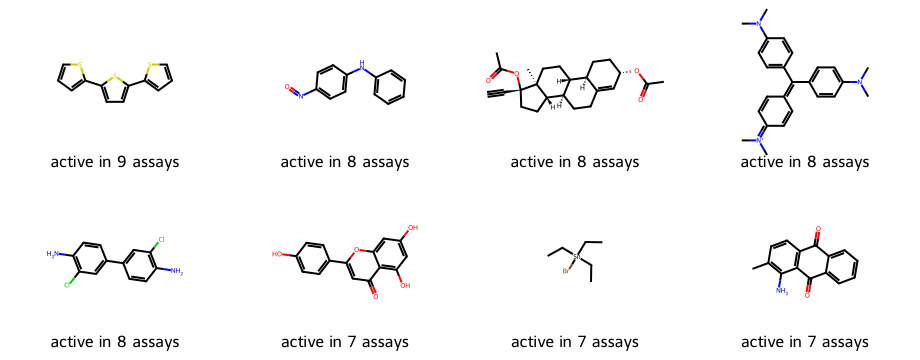

In [6]:
promiscuous = mols.assign(n_active=n_active).nlargest(8, "n_active")
mol_grid(promiscuous["smiles_clean"], [f"active in {n} assays" for n in promiscuous["n_active"]], "03_promiscuous_molecules")

## 4. Do the assays agree with each other?

If one assay's result tells us about another, a model could share information across assays (this is the idea behind *multi-task learning*).

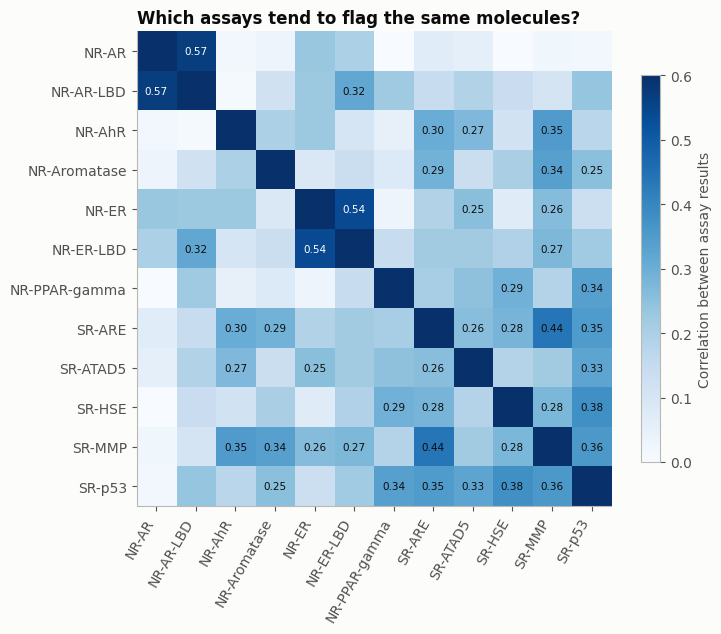

In [7]:
corr = mols[ASSAYS].corr()  # pairwise: uses molecules tested in both assays
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=0.6)
ax.set_xticks(range(len(ASSAYS)), ASSAYS, rotation=60, ha="right")
ax.set_yticks(range(len(ASSAYS)), ASSAYS)
for i in range(len(ASSAYS)):
    for j in range(len(ASSAYS)):
        if i != j and corr.iloc[i, j] >= 0.25:
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if corr.iloc[i, j] > 0.45 else style.TEXT)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="Correlation between assay results")
ax.set_title("Which assays tend to flag the same molecules?")
save_fig("04_assay_correlation")
plt.show()

- The strongest pairs are the **same receptor tested two ways**: AR with AR-LBD (0.57) and ER with ER-LBD (0.54). This is a reassuring sanity check on the data.
- The **stress-response** assays form a loose cluster (ARE, MMP, HSE, p53, with correlations of 0.35–0.44). Cell stress tends to come in packages.
- Most other pairs are close to zero. Each assay captures a largely separate biological effect, so we will build **one model per assay**.

## 5. What do active molecules look like?

Compare simple properties of molecules that are active in at least one assay with those that are inactive everywhere.

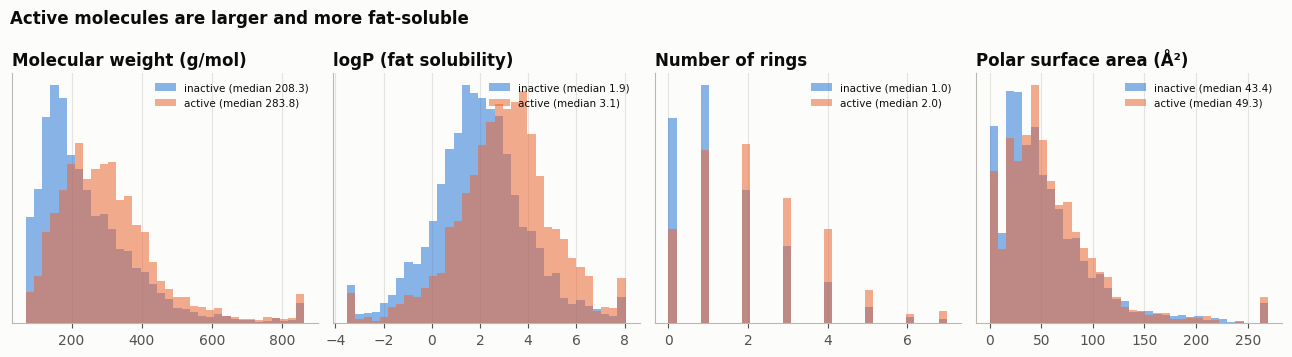

In [8]:
props = {"MolWt": "Molecular weight (g/mol)", "MolLogP": "logP (fat solubility)",
         "RingCount": "Number of rings", "TPSA": "Polar surface area (Å²)"}
any_active = n_active > 0
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, (col, label) in zip(axes, props.items()):
    lo, hi = desc[col].quantile([0.01, 0.99])
    bins = np.linspace(lo, hi, 35)
    for flag, name in [(False, "inactive"), (True, "active")]:
        ax.hist(desc.loc[any_active == flag, col].clip(lo, hi), bins=bins, density=True, alpha=0.55,
                color=style.ACTIVITY_COLORS[name], label=f"{name} (median {desc.loc[any_active == flag, col].median():.1f})")
    ax.set(title=label, yticks=[])
    ax.legend(fontsize=7.5, loc="upper right")
fig.suptitle("Active molecules are larger and more fat-soluble", x=0.01, ha="left", fontweight="bold")
save_fig("05_properties_active_vs_inactive")
plt.show()

Molecules that trigger at least one assay are, on average, **heavier** (median 284 vs 208 g/mol), **more fat-soluble** (logP 3.1 vs 1.9) and have **more rings**.
Two assays show particularly clean structure–activity relationships, both of which make biological sense:

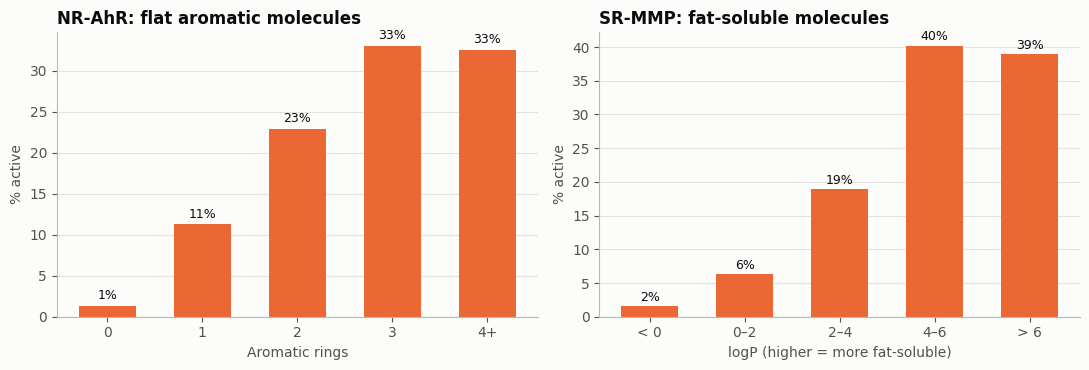

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ahr = mols.groupby(desc["NumAromaticRings"].clip(0, 4))["NR-AhR"].agg(["mean", "count"])
axes[0].bar(["0", "1", "2", "3", "4+"], ahr["mean"] * 100, color=style.ORANGE, width=0.6)
for i, v in enumerate(ahr["mean"] * 100):
    axes[0].text(i, v + 0.8, f"{v:.0f}%", ha="center", fontsize=9)
axes[0].set(xlabel="Aromatic rings", ylabel="% active", title="NR-AhR: flat aromatic molecules")

logp_bins = pd.cut(desc["MolLogP"], [-np.inf, 0, 2, 4, 6, np.inf], labels=["< 0", "0–2", "2–4", "4–6", "> 6"])
mmp = mols.groupby(logp_bins, observed=True)["SR-MMP"].mean() * 100
axes[1].bar(mmp.index.astype(str), mmp.values, color=style.ORANGE, width=0.6)
for i, v in enumerate(mmp.values):
    axes[1].text(i, v + 0.8, f"{v:.0f}%", ha="center", fontsize=9)
axes[1].set(xlabel="logP (higher = more fat-soluble)", ylabel="% active", title="SR-MMP: fat-soluble molecules")
for ax in axes:
    ax.grid(axis="x", visible=False)
save_fig("06_structure_activity")
plt.show()

- **AhR** is the receptor that dioxins and polycyclic aromatic hydrocarbons (e.g. in smoke) bind. It prefers **flat, multi-ring aromatic molecules**: activity rises from about 1% with no aromatic rings to over 30% with three or more.
- **MMP** measures damage to mitochondria. **Fat-soluble molecules** accumulate in membranes, including the mitochondrial membrane: activity rises from about 2% (logP < 0) to about 40% (logP > 4).

These patterns are exactly what a model should be able to learn from structure.

## 6. Chemical diversity: scaffolds

A molecule's **Bemis–Murcko scaffold** is its ring systems and the links between them, with side chains removed. Molecules sharing a scaffold are chemical "relatives".

Distinct scaffolds: 2,285
Molecules with no rings (no scaffold): 1,779
Scaffolds that appear only once: 1,724


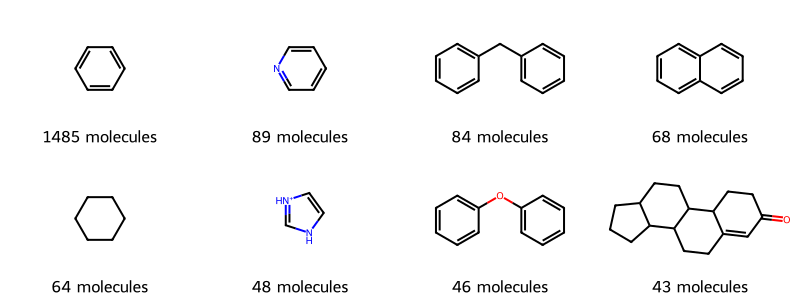

In [10]:
scaf = mols["scaffold"]
counts = scaf[scaf != ""].value_counts()
print(f"Distinct scaffolds: {scaf.nunique():,}")
print(f"Molecules with no rings (no scaffold): {(scaf == '').sum():,}")
print(f"Scaffolds that appear only once: {(counts == 1).sum():,}")
top = counts.head(8)
mol_grid(top.index, [f"{n} molecules" for n in top.values], "07_common_scaffolds", size=(200, 150))

The dataset is chemically diverse: about 2,300 distinct scaffolds, three-quarters of them appearing only once. The most common scaffold is a single benzene ring (1,485 molecules), and another 1,779 molecules have no rings at all.

This matters for evaluation. If we split molecules **at random**, close relatives of every test molecule are likely to be in the training set, and the model looks better than it is. To mimic the real use case (predicting **new** chemistry), notebook 02 also uses a **scaffold split**, where test molecules have scaffolds the model has never seen.

## Summary
- 7,823 molecules, 12 assays, 3–16% active per assay, with many missing labels.
- Assays are mostly independent, apart from the same receptor tested two ways and a loose stress-response cluster.
- Clear, biologically sensible structure–activity patterns exist: aromatic rings for AhR, fat solubility for mitochondrial toxicity.
- High chemical diversity means **how we split the data** will matter a lot.